In [1]:
import sys, os, json, warnings
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath('.'))
from vanilla_inpaint import ddpm_inpaint as ddpm_vanilla
from maya_improved import ddpm_inpaint_soft as ddpm_maya
from utils.cli import preprocess_inputs, load_sd_pipeline
from utils.image import apply_mask_for_display

STEPS          = 50
GUIDANCE_SCALE = 7.5
SEED           = 42
MASK_BIAS      = 1
MY_IMAGES_DIR  = './our_images'

/Users/mayadeshe/miniconda3/envs/inpainting-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0227 18:33:52.384000 78455 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

pairs = []
for fname in sorted(os.listdir(MY_IMAGES_DIR)):
    stem, ext = os.path.splitext(fname)
    if ext not in IMAGE_EXTENSIONS:
        continue
    if stem.endswith('_mask'):
        continue
    mask_path = os.path.join(MY_IMAGES_DIR, f"{stem}_mask.pt")
    if not os.path.exists(mask_path):
        print(f"  [skip] no mask for {fname}")
        continue
    json_path = os.path.join(MY_IMAGES_DIR, f"{stem}.json")
    caption = ""
    if os.path.exists(json_path):
        with open(json_path) as f:
            caption = json.load(f).get("caption", "")
    pairs.append({
        "img_path":  os.path.join(MY_IMAGES_DIR, fname),
        "mask_path": mask_path,
        "stem":      stem,
        "caption":   caption,
    })

print(f"Discovered {len(pairs)} image/mask pairs:\n")
for p in pairs:
    print(f"  {p['stem']:25s}  caption: {p['caption']}")

Discovered 11 image/mask pairs:

  0000                       caption: A large building with a clock at the top of it .
  Scissors                   caption: scissors
  Work-Kitchen               caption: kitchen with tables and chairs
  backgamon                  caption: backgammon board
  backyard                   caption: backyard with synthetic grass
  disney                     caption: disney castle
  fence                      caption: white stripy fence
  ferrari                    caption: red ferrari
  flower                     caption: pink flower
  pan                        caption: a non-stick pan
  pot                        caption: a large bright pot


In [3]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f'Using device: {device}')
pipe = load_sd_pipeline(device)
pipe.set_progress_bar_config(disable=True)
print('Model loaded.')

Using device: mps


Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 19.83it/s]


Model loaded.


Images:   0%|          | 0/11 [00:00<?, ?it/s]

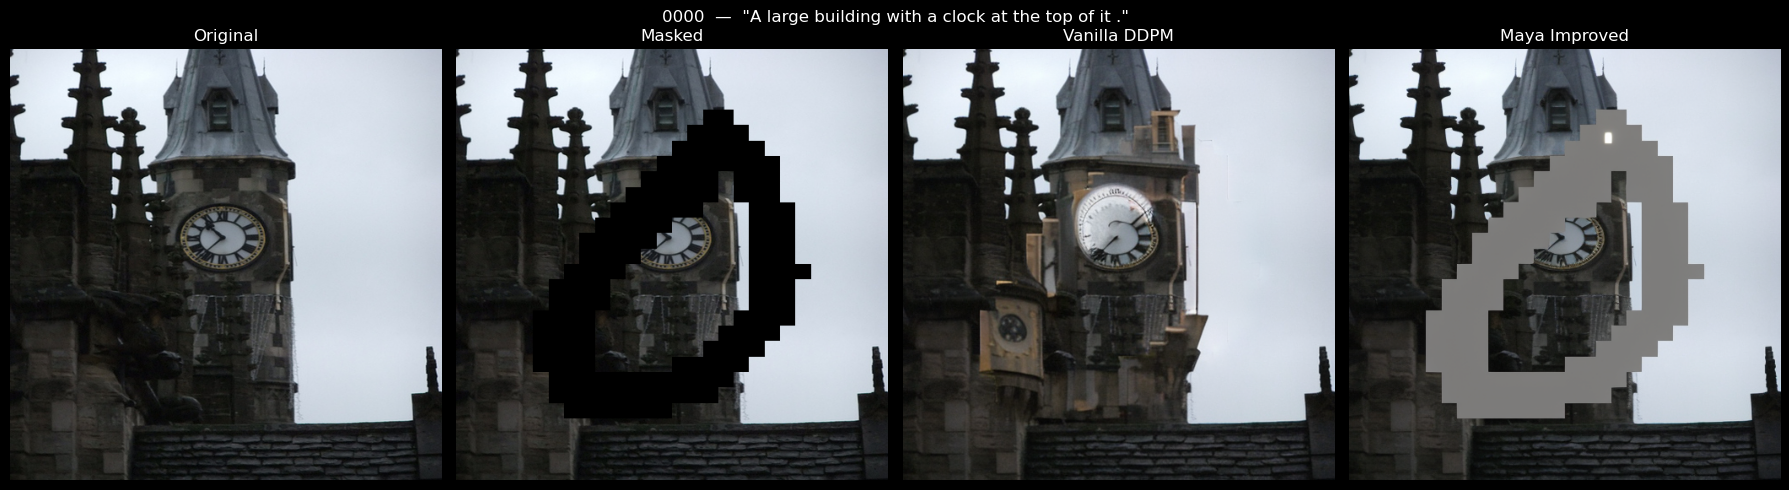

Images:   9%|▉         | 1/11 [00:42<07:02, 42.29s/it]

Saved: ./output_maya_improved/0000_comparison.png


Images:   9%|▉         | 1/11 [01:01<10:18, 61.90s/it]


KeyboardInterrupt: 

In [ ]:
out_dir = './output_maya_improved'
os.makedirs(out_dir, exist_ok=True)

for p in tqdm(pairs, desc='Images'):
    prompt = p['caption']
    original_pil, mask = preprocess_inputs(p['img_path'], p['mask_path'])

    result_vanilla = ddpm_vanilla(
        pipe, original_pil, mask, prompt, STEPS, GUIDANCE_SCALE, SEED
    )
    result_maya = ddpm_maya(
        pipe, original_pil, mask, prompt, STEPS, GUIDANCE_SCALE, SEED, MASK_BIAS
    )
    masked_viz = apply_mask_for_display(original_pil, mask)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(f"{p['stem']}  —  \"{prompt}\"", fontsize=12)

    axes[0].imshow(original_pil);     axes[0].set_title('Original');       axes[0].axis('off')
    axes[1].imshow(masked_viz);       axes[1].set_title('Masked');          axes[1].axis('off')
    axes[2].imshow(result_vanilla);   axes[2].set_title('Vanilla DDPM');    axes[2].axis('off')
    axes[3].imshow(result_maya);      axes[3].set_title('Maya Improved');   axes[3].axis('off')

    plt.tight_layout()
    save_path = os.path.join(out_dir, f"{p['stem']}_comparison.png")
    fig.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")